In [1]:
import sys
import sklearn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# !pip install category_encoders

In [2]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [3]:
print("laptop cost estimate")

laptop cost estimate


In [4]:
# from google.colab import drive
# drive.mount('/content/drive')

alternate method

In [6]:
ld = pd.read_csv("Dataset-Laptops.csv")

In [7]:
ld.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   TypeName          1303 non-null   str    
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   str    
 5   Cpu               1303 non-null   str    
 6   Ram               1303 non-null   str    
 7   Memory            1303 non-null   str    
 8   Gpu               1303 non-null   str    
 9   OpSys             1303 non-null   str    
 10  Weight            1303 non-null   str    
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), str(9)
memory usage: 122.3 KB


In [8]:
ld.describe()

,ID,Inches,Price
count,1303.00000,1303.000000,1303.000000
mean,651.00000,15.017191,59870.042910
std,376.28801,1.426304,37243.201786
min,0.00000,10.100000,9270.720000
25%,325.50000,14.000000,31914.720000
50%,651.00000,15.600000,52054.560000
75%,976.50000,15.600000,79274.246400
max,1302.00000,18.400000,324954.720000


In [9]:
ld.tail(3)

,ID,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92
1302,1302,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32


In [10]:
print(ld.shape)

(1303, 12)


In [11]:
laptop_cat = ld.select_dtypes(include=['object', 'category']).columns.tolist()
laptop_num = ld.select_dtypes(include=['number']).columns.tolist()

print("Categorical Features:", laptop_cat)
print("Numerical Features:", laptop_num)

Categorical Features: ['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight']
Numerical Features: ['ID', 'Inches', 'Price']


/var/folders/40/y23pyn757t7_mmd6zxqx59240000gn/T/ipykernel_51772/4032023458.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  laptop_cat = ld.select_dtypes(include=['object', 'category']).columns.tolist()


In [12]:
from sklearn.preprocessing import StandardScaler

# Get numerical features (excluding 'ID')
laptop_num = ld.select_dtypes(include=['number']).columns.tolist()
laptop_num = [col for col in laptop_num if col not in ['ID','Price']]  # Exclude 'ID' if present , 'Price' will be scaled later after split

# Iterate through numerical columns and apply StandardScaler, replacing in place
for col in laptop_num:
    # Min Max can also be used
    # Logarithmic
    # Robust
    std_scaler = StandardScaler()  # Initialize a new scaler for each column
    ld[col] = std_scaler.fit_transform(ld[[col]]) # Replace the original column with scaled values
ld.tail(3 )

,ID,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1300,1300,Lenovo,Notebook,-0.713439,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.12
1301,1301,HP,Notebook,0.408772,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.92
1302,1302,Asus,Notebook,0.408772,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.2kg,19660.32


In [13]:
print("convert object to number - encoding")

convert object to number - encoding


In [14]:
print(ld["Company"].value_counts())
print(ld['Company'].nunique())

Company
Dell         297
Lenovo       297
HP           274
Asus         158
Acer         103
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64
19


In [15]:
print(ld["TypeName"].value_counts())
print(ld['TypeName'].nunique())

TypeName
Notebook              727
Gaming                205
Ultrabook             196
2 in 1 Convertible    121
Workstation            29
Netbook                25
Name: count, dtype: int64
6


In [16]:
print(ld["ScreenResolution"].value_counts())
print(ld['ScreenResolution'].nunique())

ScreenResolution
Full HD 1920x1080                                507
1366x768                                         281
IPS Panel Full HD 1920x1080                      230
IPS Panel Full HD / Touchscreen 1920x1080         53
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
IPS Panel 1366x768                                 7
Touchscreen 2560x1440                              7
4K Ultra HD 3840x2160                              7
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Quad HD+ / Touchscreen 3200x1800         6
IPS Panel Touchscreen 2560x14

In [17]:
print(ld["Gpu"].value_counts())
print(ld['Gpu'].nunique())

Gpu
Intel HD Graphics 620      281
Intel HD Graphics 520      185
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
Nvidia Quadro M500M          1
AMD Radeon R7 M360           1
Nvidia Quadro M3000M         1
Nvidia GeForce 960M          1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64
110


In [18]:
print(ld["Cpu"].value_counts())
print(ld['Cpu'].nunique())

Cpu
Intel Core i5 7200U 2.5GHz              190
Intel Core i7 7700HQ 2.8GHz             146
Intel Core i7 7500U 2.7GHz              134
Intel Core i7 8550U 1.8GHz               73
Intel Core i5 8250U 1.6GHz               72
                                       ... 
Intel Core i5 7200U 2.7GHz                1
Intel Pentium Dual Core 4405Y 1.5GHz      1
Intel Core M 6Y54 1.1GHz                  1
Samsung Cortex A72&A53 2.0GHz             1
AMD E-Series 9000 2.2GHz                  1
Name: count, Length: 118, dtype: int64
118


In [19]:
print(ld["OpSys"].value_counts())
print(ld['OpSys'].nunique())

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         27
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64
9


In [20]:
print(ld["Memory"].value_counts())
print(ld['Memory'].nunique())

Memory
256GB SSD                        412
1TB HDD                          223
500GB HDD                        132
512GB SSD                        118
128GB SSD +  1TB HDD              94
128GB SSD                         76
256GB SSD +  1TB HDD              73
32GB Flash Storage                38
2TB HDD                           16
64GB Flash Storage                15
512GB SSD +  1TB HDD              14
1TB SSD                           14
256GB SSD +  2TB HDD              10
1.0TB Hybrid                       9
256GB Flash Storage                8
16GB Flash Storage                 7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
16GB SSD                           3
512GB SSD +  2TB HDD               3
256GB SSD +  256GB SSD             2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
1TB SSD +  1TB HDD                 2
512GB Flash Storage                2
64GB SSD                       

In [21]:
ld.info()


<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   TypeName          1303 non-null   str    
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   str    
 5   Cpu               1303 non-null   str    
 6   Ram               1303 non-null   str    
 7   Memory            1303 non-null   str    
 8   Gpu               1303 non-null   str    
 9   OpSys             1303 non-null   str    
 10  Weight            1303 non-null   str    
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), str(9)
memory usage: 122.3 KB


In [22]:
ld = ld.copy()

ld['Ram'] = (
    ld['Ram']
    .str.replace('GB', '', case=False, regex=False)
    .str.strip()
    .astype(int)
)

ld['Weight'] = (
    ld['Weight']
    .str.replace('Kg', '', case=False, regex=False)
    .str.strip()
    .astype(float)
)

In [23]:
ld.tail(3)

,ID,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1300,1300,Lenovo,Notebook,-0.713439,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.12
1301,1301,HP,Notebook,0.408772,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.92
1302,1302,Asus,Notebook,0.408772,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4,500GB HDD,Intel HD Graphics,Windows 10,2.20,19660.32


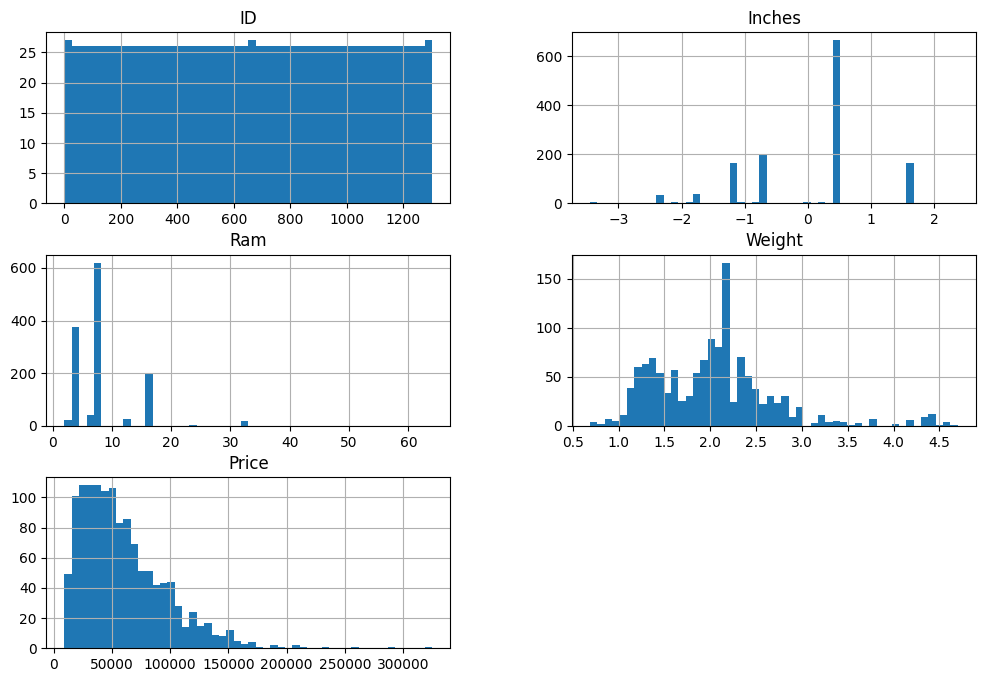

In [24]:
ld.hist(bins=50, figsize=(12,8))
plt.show()

Few brands (e.g., < 20) - One-hot encoding
Many brands (e.g., > 50)-  Target encoding
Using tree-based models - One-hot is often safer
Using linear models	- Target encoding may help
Categories have pricing hierarchy (e.g., Apple > Lenovo) - Target encoding

In [25]:
def frequency_encoding(df, column):
  frequencies = df[column].value_counts(normalize=True)
  encoded_column = df[column].map(frequencies)
  df[column + '_freq_encoded'] = encoded_column
  return df
ld = frequency_encoding(ld, 'Company')

In [26]:
ld.tail(3)

,ID,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Company_freq_encoded
1300,1300,Lenovo,Notebook,-0.713439,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.12,0.227936
1301,1301,HP,Notebook,0.408772,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.92,0.210284
1302,1302,Asus,Notebook,0.408772,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4,500GB HDD,Intel HD Graphics,Windows 10,2.20,19660.32,0.121259


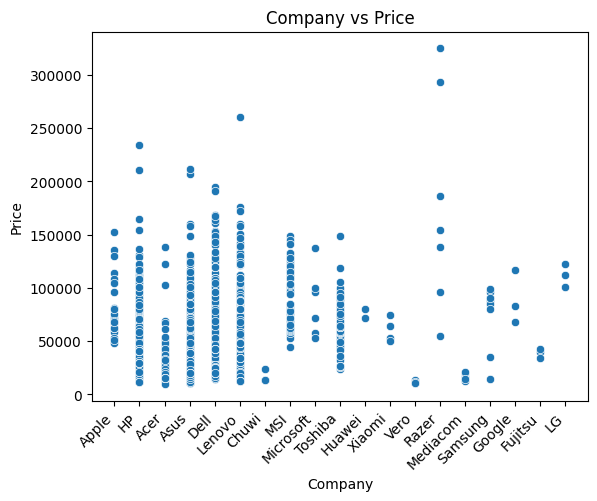

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot
sns.scatterplot(x='Company', y='Price', data=ld)

# Customize the plot (optional)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('Company vs Price')
plt.xlabel('Company')
plt.ylabel('Price')

# Display the plot
plt.show()

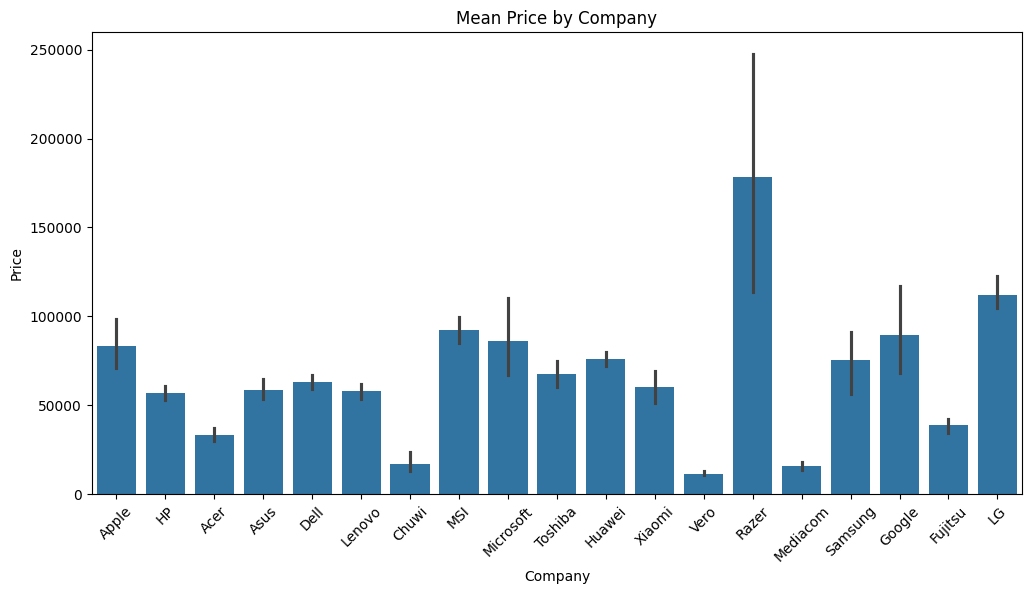

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=ld,
    x='Company',
    y='Price',
    estimator='mean'
)

plt.xticks(rotation=45)
plt.title("Mean Price by Company")
plt.show()

In [29]:
lp_type_means = ld.groupby('Company')['Price'].mean()
ld['Company_cat_encoded'] = ld['Company'].map(lp_type_means)

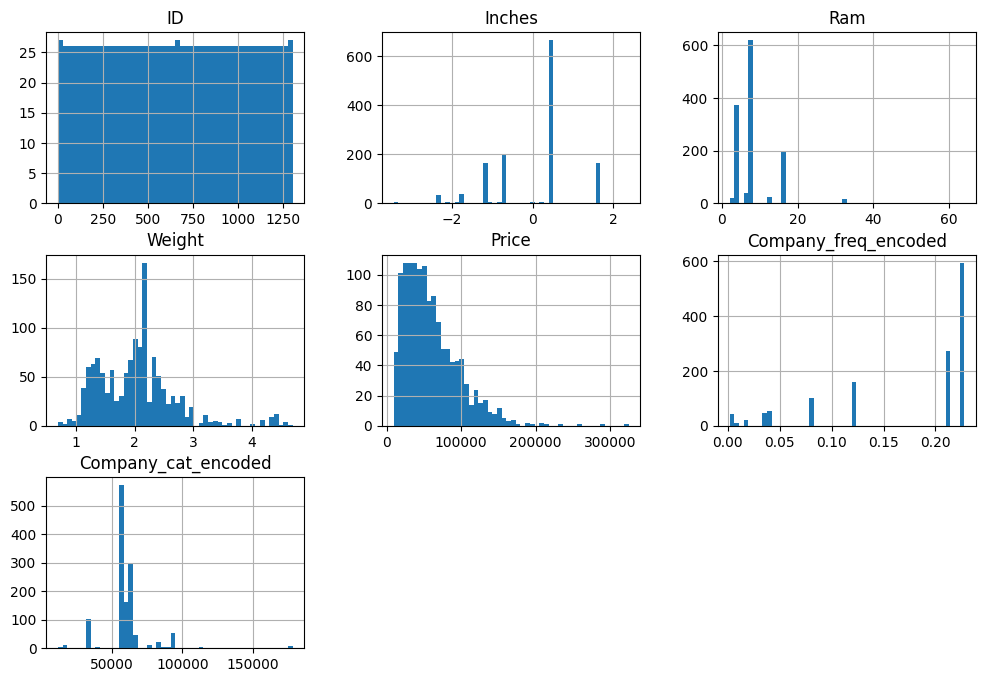

In [30]:
ld.hist(bins=50, figsize=(12,8))
plt.show()

In [31]:
ld['CPU_Brand'] = ld['Cpu'].str.extract(r'(^\w+)')         # Intel, AMD, Apple
ld['CPU_Series'] = ld['Cpu'].str.extract(r'(i\d| \d)') # i3, i5, Ryzen 5, etc.

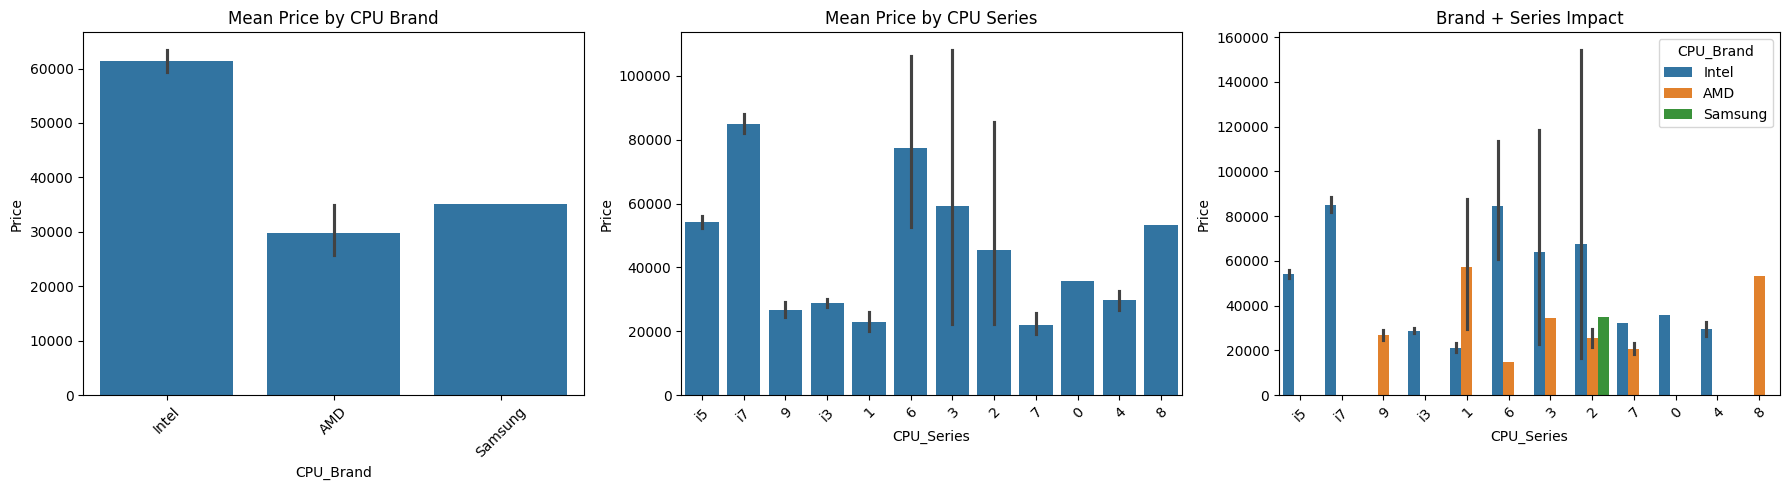

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18,5))

# Brand Impact
plt.subplot(1,3,1)
sns.barplot(
    data=ld,
    x='CPU_Brand',
    y='Price',
    estimator='mean'
)
plt.title("Mean Price by CPU Brand")
plt.xticks(rotation=45)


# Series Impact
plt.subplot(1,3,2)
sns.barplot(
    data=ld,
    x='CPU_Series',
    y='Price',
    estimator='mean'
)
plt.title("Mean Price by CPU Series")
plt.xticks(rotation=45)


# Combined Effect
plt.subplot(1,3,3)
sns.barplot(
    data=ld,
    x='CPU_Series',
    y='Price',
    hue='CPU_Brand',
    estimator='mean'
)
plt.title("Brand + Series Impact")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



In [33]:
ld.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    1303 non-null   int64  
 1   Company               1303 non-null   str    
 2   TypeName              1303 non-null   str    
 3   Inches                1303 non-null   float64
 4   ScreenResolution      1303 non-null   str    
 5   Cpu                   1303 non-null   str    
 6   Ram                   1303 non-null   int64  
 7   Memory                1303 non-null   str    
 8   Gpu                   1303 non-null   str    
 9   OpSys                 1303 non-null   str    
 10  Weight                1303 non-null   float64
 11  Price                 1303 non-null   float64
 12  Company_freq_encoded  1303 non-null   float64
 13  Company_cat_encoded   1303 non-null   float64
 14  CPU_Brand             1303 non-null   str    
 15  CPU_Series            1303 non-n

Mean Price by Brand:

CPU_Brand
AMD        29870.839045
Intel      61389.969654
Samsung    35111.520000
Name: Price, dtype: float64 

Mean Price by Family:

CPU_Family
A10-Series     30599.680800
A12-Series     34902.196200
A4-Series      20193.120000
A6-Series      21570.068945
A8-Series      23896.080000
A9-Series      26009.603576
Atom           16778.527754
Celeron        17013.823691
Core           66016.502995
Cortex         35111.520000
E-Series       16031.300800
FX             45234.720000
Pentium        23205.571200
Ryzen          89803.440000
Xeon          190955.520000
Name: Price, dtype: float64 

Correlation between GHz and Price:
          CPU_GHz     Price
CPU_GHz  1.000000  0.430293
Price    0.430293  1.000000 



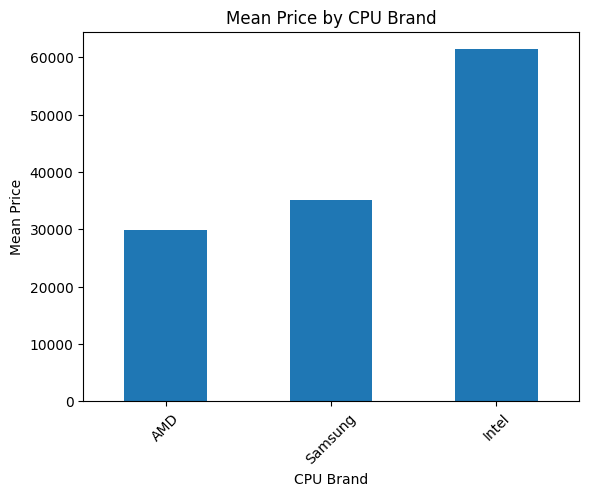

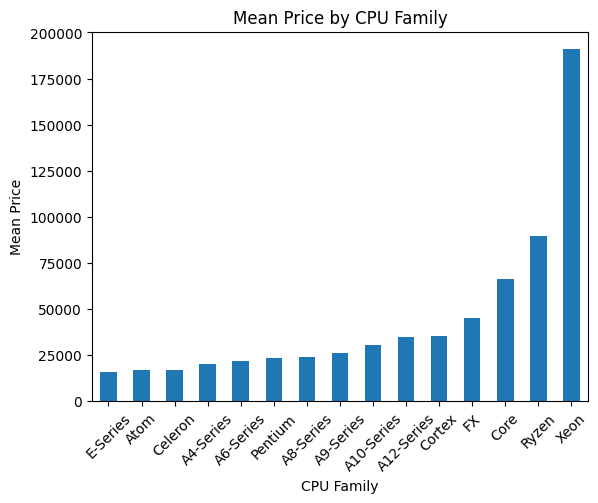

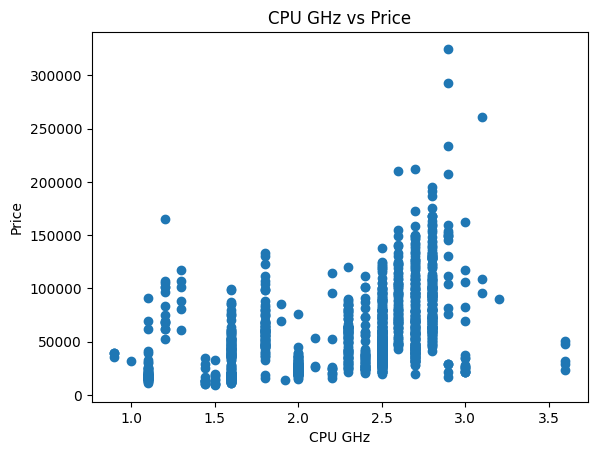

In [34]:
import re
ld = ld.copy()

# ============================================================
# CLEAN STRUCTURED CPU PARSER (Brand, Family, Model, GHz)
# ============================================================

def clean_cpu_parser(cpu_string):
    if pd.isna(cpu_string):
        return pd.Series([None]*4,
                         index=['CPU_Brand','CPU_Family','CPU_Model','CPU_GHz'])

    tokens = cpu_string.split()

    # Brand
    brand = tokens[0]

    # Extract GHz
    ghz_match = re.search(r'(\d+\.?\d*)\s?GHz', cpu_string)
    ghz = float(ghz_match.group(1)) if ghz_match else None

    # Remove GHz for cleaner parsing
    cpu_clean = re.sub(r'(\d+\.?\d*)\s?GHz', '', cpu_string).strip()
    tokens = cpu_clean.split()

    # Family (second token if exists)
    family = tokens[1] if len(tokens) > 1 else None

    # Model (last token containing digit)
    model = None
    for t in reversed(tokens):
        if re.search(r'\d', t):
            model = t
            break

    return pd.Series([brand, family, model, ghz],
                     index=['CPU_Brand','CPU_Family','CPU_Model','CPU_GHz'])

ld[['CPU_Brand','CPU_Family','CPU_Model','CPU_GHz']] = ld['Cpu'].apply(clean_cpu_parser)

# ============================================================
# NUMERIC IMPACT ANALYSIS
# ============================================================

print("Mean Price by Brand:\n")
print(ld.groupby('CPU_Brand')['Price'].mean(), "\n")

print("Mean Price by Family:\n")
print(ld.groupby('CPU_Family')['Price'].mean(), "\n")

print("Correlation between GHz and Price:")
print(ld[['CPU_GHz','Price']].corr(), "\n")

# ============================================================
# PLOT 1 — Brand Impact
# ============================================================

brand_mean = ld.groupby('CPU_Brand')['Price'].mean().sort_values()

plt.figure()
brand_mean.plot(kind='bar')
plt.title("Mean Price by CPU Brand")
plt.xlabel("CPU Brand")
plt.ylabel("Mean Price")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# PLOT 2 — Family Impact
# ============================================================

family_mean = ld.groupby('CPU_Family')['Price'].mean().sort_values()

plt.figure()
family_mean.plot(kind='bar')
plt.title("Mean Price by CPU Family")
plt.xlabel("CPU Family")
plt.ylabel("Mean Price")
plt.xticks(rotation=45)
plt.show()

# ============================================================
# PLOT 3 — GHz Impact (Scatter)
# ============================================================

plt.figure()
plt.scatter(ld['CPU_GHz'], ld['Price'])
plt.title("CPU GHz vs Price")
plt.xlabel("CPU GHz")
plt.ylabel("Price")
plt.show()

In [35]:
ld.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    1303 non-null   int64  
 1   Company               1303 non-null   str    
 2   TypeName              1303 non-null   str    
 3   Inches                1303 non-null   float64
 4   ScreenResolution      1303 non-null   str    
 5   Cpu                   1303 non-null   str    
 6   Ram                   1303 non-null   int64  
 7   Memory                1303 non-null   str    
 8   Gpu                   1303 non-null   str    
 9   OpSys                 1303 non-null   str    
 10  Weight                1303 non-null   float64
 11  Price                 1303 non-null   float64
 12  Company_freq_encoded  1303 non-null   float64
 13  Company_cat_encoded   1303 non-null   float64
 14  CPU_Brand             1303 non-null   str    
 15  CPU_Series            1303 non-n

In [36]:
ld['CPU_Brand'] = ld['CPU_Brand'].fillna('Unknown')
ld['CPU_Family'] = ld['CPU_Family'].fillna('Unknown')
ld['CPU_Model'] = ld['CPU_Model'].fillna('Unknown')
# If still missing
ld['CPU_GHz'] = ld['CPU_GHz'].fillna(ld['CPU_GHz'].median())

In [37]:
import  category_encoders as ce
ld_feat = ld.copy()

# ------------------------------------------------------------
# Convert Brand into single numeric feature (Target Mean)
# ------------------------------------------------------------

brand_mean = ld_feat.groupby('CPU_Brand')['Price'].mean()
ld_feat['CPU_Brand_TE'] = ld_feat['CPU_Brand'].map(brand_mean)

# ------------------------------------------------------------
# Convert Family into single numeric feature (Target Mean)
# ------------------------------------------------------------

family_mean = ld_feat.groupby('CPU_Family')['Price'].mean()
ld_feat['CPU_Family_TE'] = ld_feat['CPU_Family'].map(family_mean)

# ------------------------------------------------------------
# Convert Model into single numeric feature (Target Mean)
# ------------------------------------------------------------

model_mean = ld_feat.groupby('CPU_Model')['Price'].mean()
ld_feat['CPU_Model_TE'] = ld_feat['CPU_Model'].map(model_mean)


# ------------------------------------------------------------
# Convert Model into numeric generation proxy (extract leading digits)
# ------------------------------------------------------------

ld_feat['CPU_Model_Num'] = (
    ld_feat['CPU_Model']
    .str.extract(r'(\d+)')[0]
)
ld_feat['CPU_Model_Num'] = pd.to_numeric(ld_feat['CPU_Model_Num'], errors='coerce')


#------------------------------------------------------------
# overall impact
#------------------------------------------------------------
encoder = ce.TargetEncoder(cols=['Cpu'])

ld_feat['CPU_TE']= ld['CPU_TE'] = encoder.fit_transform(
    ld[['Cpu']],    # double brackets
    ld['Price']
)

# ------------------------------------------------------------
#Compute Correlations with Price
# ------------------------------------------------------------

features = ['CPU_GHz','CPU_Brand_TE','CPU_Family_TE','CPU_Model_Num','CPU_Model_TE','CPU_TE','Price']

corr_values = ld_feat[features].corr()['Price'].sort_values(ascending=False)

print("Feature-Level Correlation with Price:\n")
print(corr_values)

Feature-Level Correlation with Price:

Price            1.000000
CPU_Model_TE     0.799813
CPU_TE           0.654484
CPU_Family_TE    0.477055
CPU_GHz          0.430293
CPU_Brand_TE     0.181168
CPU_Model_Num    0.166272
Name: Price, dtype: float64


In [38]:
ld.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    1303 non-null   int64  
 1   Company               1303 non-null   str    
 2   TypeName              1303 non-null   str    
 3   Inches                1303 non-null   float64
 4   ScreenResolution      1303 non-null   str    
 5   Cpu                   1303 non-null   str    
 6   Ram                   1303 non-null   int64  
 7   Memory                1303 non-null   str    
 8   Gpu                   1303 non-null   str    
 9   OpSys                 1303 non-null   str    
 10  Weight                1303 non-null   float64
 11  Price                 1303 non-null   float64
 12  Company_freq_encoded  1303 non-null   float64
 13  Company_cat_encoded   1303 non-null   float64
 14  CPU_Brand             1303 non-null   str    
 15  CPU_Series            1303 non-n

In [39]:
ld1 = ld.copy()
ld1.info()
ld1.drop(columns=['Cpu'], inplace=True)
ld1.drop(columns=['Company'], inplace=True)
ld1.drop(columns=['Company_freq_encoded'], inplace=True)
ld1.drop(columns=['ID'], inplace=True)
ld1.drop(columns=['CPU_Brand'], inplace=True)
ld1.drop(columns=['CPU_Family'], inplace=True)
ld1.drop(columns=['CPU_Model'], inplace=True)
ld1.drop(columns=['CPU_Series'], inplace=True)
ld1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ID                    1303 non-null   int64  
 1   Company               1303 non-null   str    
 2   TypeName              1303 non-null   str    
 3   Inches                1303 non-null   float64
 4   ScreenResolution      1303 non-null   str    
 5   Cpu                   1303 non-null   str    
 6   Ram                   1303 non-null   int64  
 7   Memory                1303 non-null   str    
 8   Gpu                   1303 non-null   str    
 9   OpSys                 1303 non-null   str    
 10  Weight                1303 non-null   float64
 11  Price                 1303 non-null   float64
 12  Company_freq_encoded  1303 non-null   float64
 13  Company_cat_encoded   1303 non-null   float64
 14  CPU_Brand             1303 non-null   str    
 15  CPU_Series            1303 non-n

In [40]:
ld['GPU_Brand'] = ld['Gpu'].str.extract(r'(^\w+)')         # NVidia, Intel
ld['GPU_Series'] = ld['Gpu'].str.extract(r'(i\d|Quadro \d)') # i3, i5, Ryzen 5, etc.

# 2. Encode them
from sklearn.preprocessing import OneHotEncoder
df_encoded = pd.get_dummies(ld[['GPU_Brand', 'GPU_Series']], drop_first=True)

import category_encoders as ce

# 3. Target encode full CPU string
encoder = ce.TargetEncoder(cols=['Gpu'])
ld['GPU_TE'] = encoder.fit_transform(ld['Gpu'], ld['Price'])

In [41]:
encoder_cpu = ce.TargetEncoder(cols=['Memory'])
ld['Memory_TE'] = encoder_cpu.fit_transform(ld['Memory'], ld['Price'])

Mean Price by Memory Type:



KeyError: 'Memory'

In [42]:
cpu_type_means = ld.groupby('Cpu')['Price'].mean()
ld['CPU_cat_encoded'] = ld['Cpu'].map(cpu_type_means)

In [43]:
gpu_type_means = ld.groupby('Gpu')['Price'].mean()
ld['GPU_cat_encoded'] = ld['Gpu'].map(gpu_type_means)

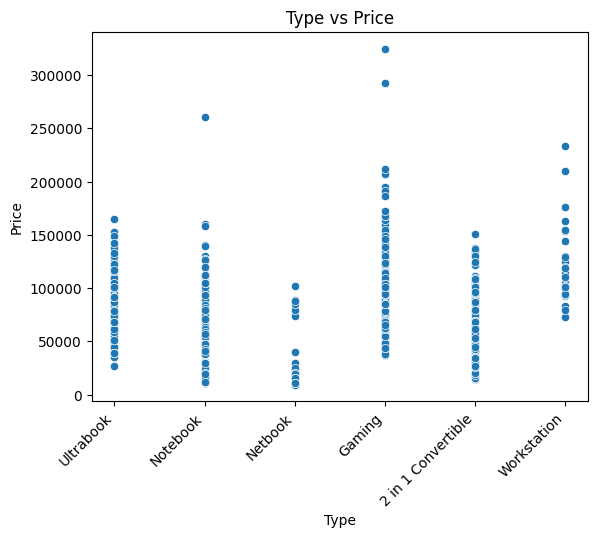

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot
sns.scatterplot(x='TypeName', y='Price', data=ld)

# Customize the plot (optional)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('Type vs Price')
plt.xlabel('Type')
plt.ylabel('Price')

# Display the plot
plt.show()

In [45]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # sparse=False for a dense array
encoded_data = encoder.fit_transform(ld[['TypeName']])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['TypeName']))
ld = pd.concat([ld, encoded_df], axis=1)
print(ld.head())

   ID Company   TypeName    Inches                    ScreenResolution  \
0   0   Apple  Ultrabook -1.204407  IPS Panel Retina Display 2560x1600   
1   1   Apple  Ultrabook -1.204407                            1440x900   
2   2      HP   Notebook  0.408772                   Full HD 1920x1080   
3   3   Apple  Ultrabook  0.268495  IPS Panel Retina Display 2880x1800   
4   4   Apple  Ultrabook -1.204407  IPS Panel Retina Display 2560x1600   

                          Cpu  Ram               Memory  \
0        Intel Core i5 2.3GHz    8            128GB SSD   
1        Intel Core i5 1.8GHz    8  128GB Flash Storage   
2  Intel Core i5 7200U 2.5GHz    8            256GB SSD   
3        Intel Core i7 2.7GHz   16            512GB SSD   
4        Intel Core i5 3.1GHz    8            256GB SSD   

                            Gpu  OpSys  ...        GPU_TE     Memory_TE  \
0  Intel Iris Plus Graphics 640  macOS  ...  67767.161692  37791.859062   
1        Intel HD Graphics 6000  macOS  ...  58888

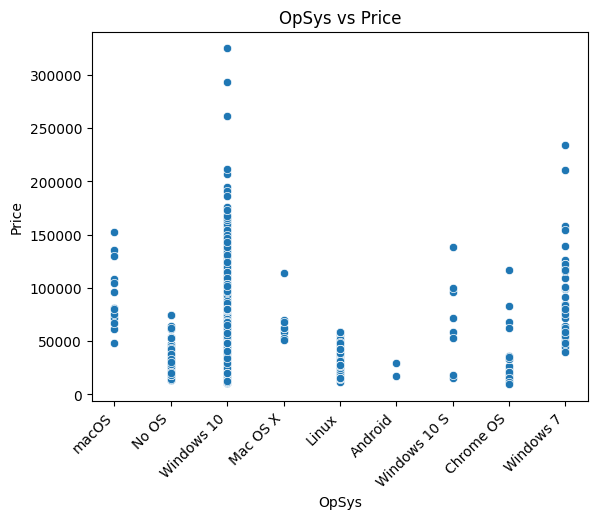

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot
sns.scatterplot(x='OpSys', y='Price', data=ld)

# Customize the plot (optional)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('OpSys vs Price')
plt.xlabel('OpSys')
plt.ylabel('Price')

# Display the plot
plt.show()

In [47]:
ld.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           1303 non-null   int64  
 1   Company                      1303 non-null   str    
 2   TypeName                     1303 non-null   str    
 3   Inches                       1303 non-null   float64
 4   ScreenResolution             1303 non-null   str    
 5   Cpu                          1303 non-null   str    
 6   Ram                          1303 non-null   int64  
 7   Memory                       1303 non-null   str    
 8   Gpu                          1303 non-null   str    
 9   OpSys                        1303 non-null   str    
 10  Weight                       1303 non-null   float64
 11  Price                        1303 non-null   float64
 12  Company_freq_encoded         1303 non-null   float64
 13  Company_cat_encoded          

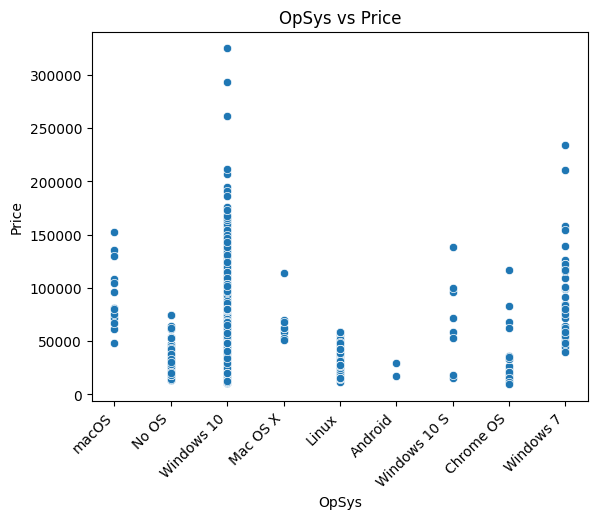

In [48]:
sns.scatterplot(x='OpSys', y='Price', data=ld)
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('OpSys vs Price')
plt.xlabel('OpSys')
plt.ylabel('Price')
plt.show()

In [49]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')  # sparse=False for a dense array
encoded_data = encoder.fit_transform(ld[['OpSys']])
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['OpSys']))
ld = pd.concat([ld, encoded_df], axis=1)
print(ld.head())

   ID Company   TypeName    Inches                    ScreenResolution  \
0   0   Apple  Ultrabook -1.204407  IPS Panel Retina Display 2560x1600   
1   1   Apple  Ultrabook -1.204407                            1440x900   
2   2      HP   Notebook  0.408772                   Full HD 1920x1080   
3   3   Apple  Ultrabook  0.268495  IPS Panel Retina Display 2880x1800   
4   4   Apple  Ultrabook -1.204407  IPS Panel Retina Display 2560x1600   

                          Cpu  Ram               Memory  \
0        Intel Core i5 2.3GHz    8            128GB SSD   
1        Intel Core i5 1.8GHz    8  128GB Flash Storage   
2  Intel Core i5 7200U 2.5GHz    8            256GB SSD   
3        Intel Core i7 2.7GHz   16            512GB SSD   
4        Intel Core i5 3.1GHz    8            256GB SSD   

                            Gpu  OpSys  ...  TypeName_Workstation  \
0  Intel Iris Plus Graphics 640  macOS  ...                   0.0   
1        Intel HD Graphics 6000  macOS  ...                   

In [50]:
def frequency_encoding(df, column):
  """
  Applies frequency encoding to a categorical column in a DataFrame.

  Args:
    df: The pandas DataFrame containing the data.
    column: The name of the categorical column to encode.

  Returns:
    The DataFrame with the frequency encoded column added.
  """
  # Calculate frequency of each category
  frequencies = df[column].value_counts(normalize=True)

  # Map frequencies to the original column
  encoded_column = df[column].map(frequencies)

  # Add the encoded column to the DataFrame
  df[column + '_freq_encoded'] = encoded_column

  return df

# Apply frequency encoding to the 'CPU_cat' column in your DataFrame 'ld1'
ld1 = frequency_encoding(ld, 'ScreenResolution')

# Display the updated DataFrame
print(ld.info())

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 42 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID                             1303 non-null   int64  
 1   Company                        1303 non-null   str    
 2   TypeName                       1303 non-null   str    
 3   Inches                         1303 non-null   float64
 4   ScreenResolution               1303 non-null   str    
 5   Cpu                            1303 non-null   str    
 6   Ram                            1303 non-null   int64  
 7   Memory                         1303 non-null   str    
 8   Gpu                            1303 non-null   str    
 9   OpSys                          1303 non-null   str    
 10  Weight                         1303 non-null   float64
 11  Price                          1303 non-null   float64
 12  Company_freq_encoded           1303 non-null   float64
 13 

In [51]:
import pandas as pd
import category_encoders as ce
import re

# 1. Extract Display Type and Size
def extract_display_info(resolution_string):
    """Extracts display type and size from the ScreenResolution string."""
    match = re.search(r'(\d+)x(\d+)\s*(.*)', resolution_string)
    if match:
        width, height, display_info = match.groups()
        display_type = display_info.strip()  # Assuming display type is the remaining string
        display_size = '' # Placeholder for display size logic
        return display_type, display_size
    else:
        return '', ''

ld[['DisplayType', 'DisplaySize']] = ld['ScreenResolution'].apply(extract_display_info).apply(pd.Series)


# 2. Combo Target Encoding
combo_cols = ['ScreenResolution', 'DisplayType', 'DisplaySize']

# Initialize the TargetEncoder with smoothing
encoder = ce.TargetEncoder(cols=combo_cols, smoothing=10)  # Adjust smoothing as needed

# Fit the encoder on your training data
encoder.fit(ld[combo_cols], ld['Price'])

# Transform the columns and select only the 'ScreenResolution' encoded column
# Instead of assigning the entire DataFrame, select the desired column:
ld['ScreenResolution_combo_encoded'] = encoder.transform(ld[combo_cols])['ScreenResolution']

#ld1['ScreenResolution_combo_encoded'] = encoder.transform(ld1[combo_cols])

In [52]:
ld.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 45 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              1303 non-null   int64  
 1   Company                         1303 non-null   str    
 2   TypeName                        1303 non-null   str    
 3   Inches                          1303 non-null   float64
 4   ScreenResolution                1303 non-null   str    
 5   Cpu                             1303 non-null   str    
 6   Ram                             1303 non-null   int64  
 7   Memory                          1303 non-null   str    
 8   Gpu                             1303 non-null   str    
 9   OpSys                           1303 non-null   str    
 10  Weight                          1303 non-null   float64
 11  Price                           1303 non-null   float64
 12  Company_freq_encoded            1303 non-null

In [53]:
# Get a list of columns with object dtype
object_cols = ld.select_dtypes(include=['object']).columns

# Drop the object columns
ld = ld.drop(columns=object_cols)

/var/folders/40/y23pyn757t7_mmd6zxqx59240000gn/T/ipykernel_51772/3793134221.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols = ld.select_dtypes(include=['object']).columns


In [54]:
ld.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              1303 non-null   int64  
 1   Inches                          1303 non-null   float64
 2   Ram                             1303 non-null   int64  
 3   Weight                          1303 non-null   float64
 4   Price                           1303 non-null   float64
 5   Company_freq_encoded            1303 non-null   float64
 6   Company_cat_encoded             1303 non-null   float64
 7   CPU_GHz                         1303 non-null   float64
 8   CPU_TE                          1303 non-null   float64
 9   GPU_TE                          1303 non-null   float64
 10  Memory_TE                       1303 non-null   float64
 11  CPU_cat_encoded                 1303 non-null   float64
 12  GPU_cat_encoded                 1303 non-null

In [55]:
ld = ld.drop(columns=["Company_freq_encoded"])

In [56]:
ld.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              1303 non-null   int64  
 1   Inches                          1303 non-null   float64
 2   Ram                             1303 non-null   int64  
 3   Weight                          1303 non-null   float64
 4   Price                           1303 non-null   float64
 5   Company_cat_encoded             1303 non-null   float64
 6   CPU_GHz                         1303 non-null   float64
 7   CPU_TE                          1303 non-null   float64
 8   GPU_TE                          1303 non-null   float64
 9   Memory_TE                       1303 non-null   float64
 10  CPU_cat_encoded                 1303 non-null   float64
 11  GPU_cat_encoded                 1303 non-null   float64
 12  TypeName_2 in 1 Convertible     1303 non-null

In [57]:
ld = ld.drop(columns=["CPU_cat_encoded"])
ld = ld.drop(columns=["GPU_cat_encoded"])

In [58]:
ld =ld.drop(columns="ScreenResolution_freq_encoded")

In [59]:
ld =ld.drop(columns="ID")

In [60]:
ld1=ld.copy()

In [61]:
ld1.info()

<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Inches                          1303 non-null   float64
 1   Ram                             1303 non-null   int64  
 2   Weight                          1303 non-null   float64
 3   Price                           1303 non-null   float64
 4   Company_cat_encoded             1303 non-null   float64
 5   CPU_GHz                         1303 non-null   float64
 6   CPU_TE                          1303 non-null   float64
 7   GPU_TE                          1303 non-null   float64
 8   Memory_TE                       1303 non-null   float64
 9   TypeName_2 in 1 Convertible     1303 non-null   float64
 10  TypeName_Gaming                 1303 non-null   float64
 11  TypeName_Netbook                1303 non-null   float64
 12  TypeName_Notebook               1303 non-null

In [62]:
print(ld1.head(2))

     Inches  Ram  Weight       Price  Company_cat_encoded  CPU_GHz  \
0 -1.204407    8    1.37  71378.6832         83340.499886      2.3   
1 -1.204407    8    1.34  47895.5232         83340.499886      1.8   

         CPU_TE        GPU_TE     Memory_TE  TypeName_2 in 1 Convertible  ...  \
0  62178.452057  67767.161692  37791.859062                          0.0  ...   
1  59153.054815  58888.758674  56149.484961                          0.0  ...   

   OpSys_Android  OpSys_Chrome OS  OpSys_Linux  OpSys_Mac OS X  OpSys_No OS  \
0            0.0              0.0          0.0             0.0          0.0   
1            0.0              0.0          0.0             0.0          0.0   

   OpSys_Windows 10  OpSys_Windows 10 S  OpSys_Windows 7  OpSys_macOS  \
0               0.0                 0.0              0.0          1.0   
1               0.0                 0.0              0.0          1.0   

   ScreenResolution_combo_encoded  
0                    65732.926374  
1              

In [63]:
# Save the modified DataFrame back to a CSV file
ld1.to_csv("laptop_data_m.csv", index=False)

In [64]:
corr_matrix = ld1.corr()
corr_matrix["Price"].sort_values(ascending=False)

Price                             1.000000
Ram                               0.743007
Memory_TE                         0.681896
CPU_TE                            0.654484
GPU_TE                            0.649540
ScreenResolution_combo_encoded    0.545037
CPU_GHz                           0.430293
Company_cat_encoded               0.404350
TypeName_Gaming                   0.375789
TypeName_Ultrabook                0.255658
TypeName_Workstation              0.249752
Weight                            0.210370
OpSys_Windows 7                   0.152381
OpSys_Windows 10                  0.137048
OpSys_macOS                       0.089928
TypeName_2 in 1 Convertible       0.072675
Inches                            0.068197
OpSys_Windows 10 S                0.018312
OpSys_Mac OS X                    0.015656
OpSys_Android                    -0.038700
TypeName_Netbook                 -0.097572
OpSys_Chrome OS                  -0.118684
OpSys_Linux                      -0.162060
OpSys_No OS

In [65]:
import numpy as np
ld1["price_cat"] = pd.cut(ld1["Price"],
                               bins=[0., 50000.0, 100000.0,np.inf],
                               labels=[1, 2, 3])

In [66]:
ld1["price_cat"].value_counts()

price_cat
1    623
2    503
3    177
Name: count, dtype: int64

In [67]:
import numpy as np
ld1["price_cat"] = pd.cut(ld1["Price"],
                               bins=[0., 50000.0, 100000.0,np.inf],
                               labels=[1, 2, 3])

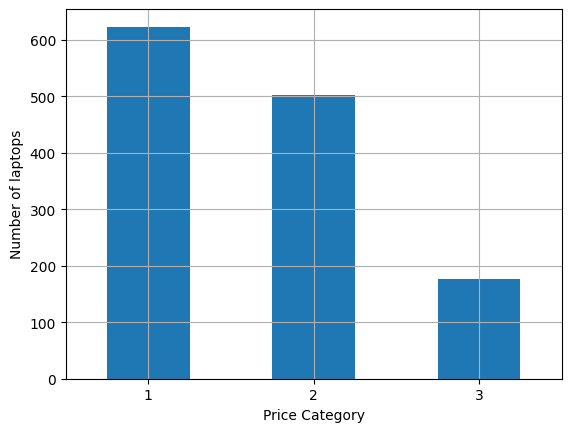

In [68]:
ld1["price_cat"].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.xlabel("Price Category")
plt.ylabel("Number of laptops")
plt.show()

# Machine Learning

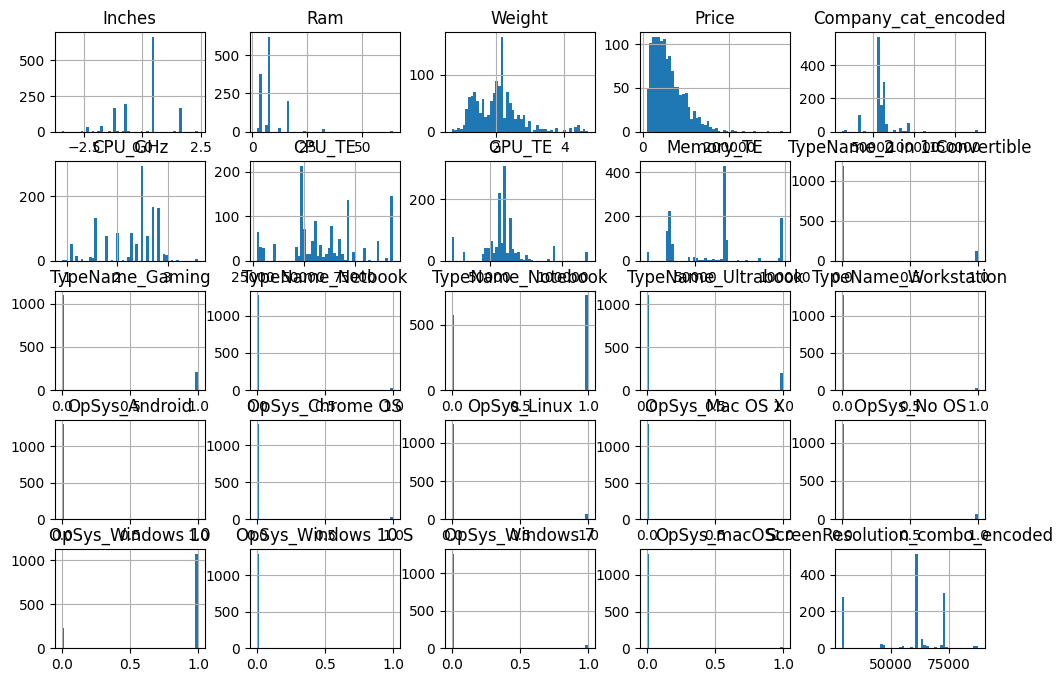

In [69]:
ld1.hist(bins=50, figsize=(12,8))
plt.show()

In [70]:
from sklearn.model_selection import StratifiedShuffleSplit
splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []  # To store multiple splits

for train_index, test_index in splitter.split(ld1, ld1["price_cat"]):
    strat_train_set_n = ld1.iloc[train_index]
    strat_test_set_n = ld1.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

In [71]:
strat_train_set, strat_test_set = strat_splits[0]
print(strat_train_set.sample())
print("training set shape:", strat_train_set.shape)
print("testing set shape: ", strat_test_set.shape)

        Inches  Ram  Weight     Price  Company_cat_encoded  CPU_GHz  \
1188 -1.204407    8    1.23  58554.72         63193.755782      2.4   

            CPU_TE        GPU_TE     Memory_TE  TypeName_2 in 1 Convertible  \
1188  65403.808606  55998.366024  65501.763414                          0.0   

      ...  OpSys_Chrome OS  OpSys_Linux  OpSys_Mac OS X  OpSys_No OS  \
1188  ...              0.0          1.0             0.0          0.0   

      OpSys_Windows 10  OpSys_Windows 10 S  OpSys_Windows 7  OpSys_macOS  \
1188               0.0                 0.0              0.0          0.0   

      ScreenResolution_combo_encoded  price_cat  
1188                    72124.049645          2  

[1 rows x 26 columns]
training set shape: (1042, 26)
testing set shape:  (261, 26)


In [72]:
strat_test_set["price_cat"].value_counts() / len(strat_test_set)

price_cat
1    0.478927
2    0.386973
3    0.134100
Name: count, dtype: float64

In [73]:
strat_train_set["price_cat"].value_counts() / len(strat_train_set)

price_cat
1    0.477927
2    0.385797
3    0.136276
Name: count, dtype: float64

In [74]:
ld1["price_cat"].value_counts() / len(ld1)

price_cat
1    0.478127
2    0.386032
3    0.135840
Name: count, dtype: float64

In [75]:
ld2=strat_train_set.copy()

In [76]:
ld2 = strat_test_set.drop("Price", axis=1)
ld2_labels= strat_test_set["Price"].copy()
print (ld2.head(2))

       Inches  Ram  Weight  Company_cat_encoded  CPU_GHz        CPU_TE  \
955  1.601121   16    4.36         63193.755782      2.8  93794.446472   
127 -0.713439    4    1.65         58830.143878      1.5  54007.519550   

            GPU_TE     Memory_TE  TypeName_2 in 1 Convertible  \
955  117833.444408  85862.492573                          0.0   
127   51696.911436  54007.519550                          0.0   

     TypeName_Gaming  ...  OpSys_Chrome OS  OpSys_Linux  OpSys_Mac OS X  \
955              1.0  ...              0.0          0.0             0.0   
127              0.0  ...              0.0          0.0             0.0   

     OpSys_No OS  OpSys_Windows 10  OpSys_Windows 10 S  OpSys_Windows 7  \
955          0.0               1.0                 0.0              0.0   
127          0.0               0.0                 1.0              0.0   

     OpSys_macOS  ScreenResolution_combo_encoded  price_cat  
955          0.0                    85250.355021          3  
127  

In [77]:
print("cleaning data")

cleaning data


In [78]:
ld1 = strat_train_set.drop("Price", axis=1)
ld1_labels= strat_train_set["Price"].copy()
print (ld1.head(2))

       Inches  Ram  Weight  Company_cat_encoded  CPU_GHz        CPU_TE  \
47   1.601121    8     3.2         58830.143878      3.0  64467.651647   
118  1.601121    4     2.0         58830.143878      2.0  26812.508832   

           GPU_TE     Memory_TE  TypeName_2 in 1 Convertible  TypeName_Gaming  \
47   65454.097879  98701.955639                          0.0              1.0   
118  51225.685222  35918.831498                          0.0              0.0   

     ...  OpSys_Chrome OS  OpSys_Linux  OpSys_Mac OS X  OpSys_No OS  \
47   ...              0.0          0.0             0.0          0.0   
118  ...              0.0          0.0             0.0          0.0   

     OpSys_Windows 10  OpSys_Windows 10 S  OpSys_Windows 7  OpSys_macOS  \
47                1.0                 0.0              0.0          0.0   
118               1.0                 0.0              0.0          0.0   

     ScreenResolution_combo_encoded  price_cat  
47                     61619.932062         

In [79]:
ld1=ld1.drop(columns="price_cat")

In [80]:
ld2=ld2.drop(columns="price_cat")

In [81]:
ld1_labels= strat_train_set["Price"].copy()
print (ld1.head(2))

       Inches  Ram  Weight  Company_cat_encoded  CPU_GHz        CPU_TE  \
47   1.601121    8     3.2         58830.143878      3.0  64467.651647   
118  1.601121    4     2.0         58830.143878      2.0  26812.508832   

           GPU_TE     Memory_TE  TypeName_2 in 1 Convertible  TypeName_Gaming  \
47   65454.097879  98701.955639                          0.0              1.0   
118  51225.685222  35918.831498                          0.0              0.0   

     ...  OpSys_Android  OpSys_Chrome OS  OpSys_Linux  OpSys_Mac OS X  \
47   ...            0.0              0.0          0.0             0.0   
118  ...            0.0              0.0          0.0             0.0   

     OpSys_No OS  OpSys_Windows 10  OpSys_Windows 10 S  OpSys_Windows 7  \
47           0.0               1.0                 0.0              0.0   
118          0.0               1.0                 0.0              0.0   

     OpSys_macOS  ScreenResolution_combo_encoded  
47           0.0                    

In [82]:
print(ld1.head(2))

       Inches  Ram  Weight  Company_cat_encoded  CPU_GHz        CPU_TE  \
47   1.601121    8     3.2         58830.143878      3.0  64467.651647   
118  1.601121    4     2.0         58830.143878      2.0  26812.508832   

           GPU_TE     Memory_TE  TypeName_2 in 1 Convertible  TypeName_Gaming  \
47   65454.097879  98701.955639                          0.0              1.0   
118  51225.685222  35918.831498                          0.0              0.0   

     ...  OpSys_Android  OpSys_Chrome OS  OpSys_Linux  OpSys_Mac OS X  \
47   ...            0.0              0.0          0.0             0.0   
118  ...            0.0              0.0          0.0             0.0   

     OpSys_No OS  OpSys_Windows 10  OpSys_Windows 10 S  OpSys_Windows 7  \
47           0.0               1.0                 0.0              0.0   
118          0.0               1.0                 0.0              0.0   

     OpSys_macOS  ScreenResolution_combo_encoded  
47           0.0                    

### 🔍 Comparison of CV Search Methods for Hyperparameter Tuning

| Method              | Best For                                 | Speed        | Exploration     | CV Built-in |
|---------------------|-------------------------------------------|--------------|------------------|-------------|
| **Grid Search**     | Small, exact search                       | ❌ Slow       | ✅ Exhaustive     | ✅ Yes       |
| **Random Search**   | Large, quick search                       | ✅ Faster     | ✅ Partial        | ✅ Yes       |
| **Bayesian Opt.**   | Expensive models, fewer trials needed     | ✅ Fast       | ✅ Smart Search   | ⚠️ Custom    |
| **Halving Search**  | Limited resources, fast pruning           | ✅ Very Fast  | ✅ Progressive    | ✅ Yes       |
| **Hyperband**       | Deep learning, early stopping             | ✅ Very Fast  | ✅ Adaptive       | ⚠️ Custom    |
| **TPOT / Genetic**  | Feature + model + param tuning            | ⚠️ Slower     | ✅ Exploratory    | ✅ Yes       |
| **AutoML Tools**    | Automated full pipeline tuning            | ✅ Fast       | ✅ All-in-One     | ✅ Yes       |


In [83]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
ridge = Ridge()
ridge_params = {
    'alpha': [0.01, 0.1, 1.0, 10.0],
    'solver': ['auto', 'svd', 'cholesky', 'lsqr']
}
ridge_grid = GridSearchCV(ridge, ridge_params, cv=10, scoring='neg_mean_squared_error')
ridge_grid.fit(ld1, ld1_labels)
print("🔹 Best Ridge Parameters:", ridge_grid.best_params_)

🔹 Best Ridge Parameters: {'alpha': 1.0, 'solver': 'svd'}


Ridge (Regularized Linear Regression)

In [84]:
predictions1 = ridge_grid.predict(ld2)

In [85]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

# Create a pipeline that includes scaling and the model
pipeline = make_pipeline(StandardScaler(), RandomForestRegressor())

# Perform 10-fold cross-validation
scores = cross_val_score(pipeline, ld1, ld1_labels, cv=10, scoring='neg_mean_squared_error')

# Calculate RMSE from the negative MSE scores
rmse_scores = np.sqrt(-scores)

# Print the results
print("RMSE scores:", rmse_scores)
print("Mean RMSE:", rmse_scores.mean())
print("Standard Deviation of RMSE:", rmse_scores.std())

rf = RandomForestRegressor(random_state=None)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(rf, rf_params, cv=10, scoring='neg_mean_squared_error', n_jobs=-1)
rf_grid.fit(ld1, ld1_labels)

print(" Best Random Forest Params:", rf_grid.best_params_)



RMSE scores: [11507.13699081 12906.20765193 13856.40342375 16598.7933799
 15490.57852228 16852.66949089 11389.33423513 21748.24110118
 17412.72608111 12674.03207467]
Mean RMSE: 15043.612295165329
Standard Deviation of RMSE: 3064.4588782052874
 Best Random Forest Params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [86]:
predictions2 = rf_grid.predict(ld2)

In [87]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(ld1_labels.to_frame())

model = DecisionTreeRegressor()
model.fit(ld1, scaled_labels)
#some_new_data = ld1.iloc[:5]


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [88]:
ld_predictions = model.predict(ld2)
predictions3 = target_scaler.inverse_transform(ld_predictions.reshape(-1,1))

In [89]:
!pip install xgboost
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(ld1_labels.values.reshape(-1,1)).ravel()

model = XGBRegressor()
model.fit(ld1, scaled_labels)
#some_new_data = ld1.iloc[:5]


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Volumes/Data/Codes/BPGC_Courses/S2_SES/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <1A0D8152-BF46-3BE0-B651-EE965C187777> /Volumes/Data/Codes/BPGC_Courses/S2_SES/.venv/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/home

In [ ]:
ld_predictions = model.predict(ld2)
predictions4 = target_scaler.inverse_transform(ld_predictions.reshape(-1,1))

In [ ]:
#some_data = ld1.iloc[:5]
#some_labels = ld1_labels.iloc[:5]
print("Predictions:", predictions1[:3])
print("Predictions:", predictions2[:3])
print("Predictions:", predictions3[:3])
print("Predictions:", predictions4[:3])

Predictions: [[4.76544066e+09]
 [1.14112618e+09]
 [3.12491287e+09]]
Predictions: [[5.44524961e+09]
 [6.76735525e+08]
 [3.58065153e+09]]
Predictions: [[152161.5528]
 [ 18594.72  ]
 [ 78694.56  ]]
Predictions: [[151629.22  ]
 [ 14765.9375]
 [ 93895.21  ]]


In [ ]:
print(ld2_labels.iloc[:3])

955    168045.1200
127     14811.3072
963     95371.2000
Name: Price, dtype: float64


In [ ]:
from sklearn.metrics import mean_squared_error

# Assuming ld2_labels contains the actual target values and
# predictions1, predictions2, predictions3 are your model predictions

# Calculate RMSE for each model's predictions
rmse1 = np.sqrt(mean_squared_error(ld2_labels, predictions1))
rmse2 = np.sqrt(mean_squared_error(ld2_labels, predictions2))
rmse3 = np.sqrt(mean_squared_error(ld2_labels, predictions3))
rmse4 = np.sqrt(mean_squared_error(ld2_labels, predictions4))
print("RMSE for Model 1:", rmse1)
print("RMSE for Model 2:", rmse2)
print("RMSE for Model 3:", rmse3)
print("RMSE for Model 4:", rmse4)

RMSE for Model 1: 16978.51153142416
RMSE for Model 2: 13652.104876201267
RMSE for Model 3: 20369.317829747655
RMSE for Model 4: 12128.890646154847


do as a piplin e and do the category like housing data

In [ ]:
import numpy as np

def average_percentage_difference(actual_prices, predicted_prices):
  # Calculate the absolute differences between actual and predicted prices
  differences = np.abs(actual_prices - predicted_prices)
  average_price = (actual_prices + predicted_prices) / 2
  percentage_differences = (differences / average_price) * 100
  average_percentage_diff = np.mean(percentage_differences)
  return average_percentage_diff

actual_prices = ld2_labels
predicted_prices1 = predictions1.flatten()
avg_percentage_diff1 = average_percentage_difference(actual_prices, predicted_prices1)
print(f"Average Percentage Difference1: {avg_percentage_diff1:.2f}%")

predicted_prices2 = predictions2.flatten()
avg_percentage_diff2 = average_percentage_difference(actual_prices, predicted_prices2)
print(f"Average Percentage Difference2: {avg_percentage_diff2:.2f}%")

predicted_prices3 = predictions3.flatten()
avg_percentage_diff3 = average_percentage_difference(actual_prices, predicted_prices3)
print(f"Average Percentage Difference3: {avg_percentage_diff3:.2f}%")

predicted_prices4 = predictions4.flatten()
avg_percentage_diff4 = average_percentage_difference(actual_prices, predicted_prices4)
print(f"Average Percentage Difference3: {avg_percentage_diff4:.2f}%")

Average Percentage Difference1: 30.66%
Average Percentage Difference2: 15.14%
Average Percentage Difference3: 21.09%
Average Percentage Difference3: 13.55%
